<a href="https://colab.research.google.com/github/miawilcox18-hub/miawilcox.github.io/blob/main/Elina_Mia_Final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [88]:
import pandas as pd
import numpy as np
import re

# **Project Goals**
The Team, **Mia Wilcox** and **Elina Xu**, are focused on the exploratory data analysis (EDA) and statistical modeling of New Orleans temperature and sea-level data. The team aims to utilize data science techniques including data cleaning, merging, and correlation analysis to quantify the relationship between rising temperatures and local sea-level changes. The website in which the analysis is located can be found [here](https://miawilcox18-hub.github.io/miawilcox.github.io/)

## **Collaboration Plans**
The team is planning to meet at least once a week, in person or on zoom. Consitent meetings will help us finalize our project and collaborate on what objectives to have at the end of the project. In order to keep in active communication with each other, we will be messaging if we have questions about anything on the project. We have a shared Github where we are both collaboraters. To stay on top of our objectives we have also created a checklist of what we want to get done every week to keep up with the milestones.

# **Table 1**

This table was created using the Global Historical Climatology Network Daily (GHCN-Daily) dataset, which is publicly available through NOAA’s National Centers for Environmental Information (NCEI) and accessible via Google BigQuery. The dataset contains daily weather observations collected from thousands of monitoring stations around the world. For this project, the team focused specifically on weather stations located in Louisiana and extracted data from 1970 through 2024. Each observation originally represented a single daily measurement recorded at a specific station, including variables such as the date of observation, the weather element measured (for example maximum or minimum temperature), and the recorded value. After collecting the full dataset, the data was tidied and aggregated so that each row represents the average monthly temperature measurements across Louisiana, including average maximum temperature, average minimum temperature, and calculated average temperature for each month.

The team chose this dataset because it provides long-term, reliable climate observations that can be used to analyze trends in temperature over time. This allows the project to explore questions such as how average temperatures in Louisiana have changed over the past several decades, whether seasonal temperature patterns have shifted, and how maximum and minimum temperatures compare across different months or years. Additionally, the dataset comes from a reputable and authoritative source, NOAA, which is widely used in climate and environmental research.

However, the team recognizes that there may still be limitations and potential sources of bias within the dataset. For example, the number and location of weather stations may vary across time, meaning some areas may be more represented than others. Additionally, aggregating daily observations into monthly averages may remove some variability or extreme events that could also be relevant to climate analysis. Despite these limitations, the dataset provides a strong and credible foundation for analyzing long-term temperature patterns in Louisiana.

In [89]:
temp_df = pd.read_csv("/content/drive/MyDrive/Data Colab Notebooks/louisiana_temp.csv") #importing louisiana temp data

temp_df.head()

,id,date,element,value,mflag,qflag,sflag,time,source_url,etl_timestamp,...,latitude,longitude,elevation,state,name,gsn_flag,hcn_crn_flag,wmoid,source_url_1,etl_timestamp_1
0,USC00160103,2017-09-06,TMIN,189.0,NaN,NaN,7,2400.0,ftp://ftp.ncei.noaa.gov/pub/data/ghcn/daily/by...,2023-07-19 20:43:46.152011 UTC,...,31.2483,-92.4486,23.5,LA,ALEXANDRIA 5 SSE,NaN,NaN,NaN,ftp://ftp.ncdc.noaa.gov/pub/data/ghcn/daily/gh...,2026-03-04 01:37:43.795564 UTC
1,USC00168444,2017-09-14,TOBS,156.0,NaN,NaN,7,700.0,ftp://ftp.ncei.noaa.gov/pub/data/ghcn/daily/by...,2023-07-19 20:44:09.594364 UTC,...,32.3794,-93.8019,57.3,LA,SHREVEPORT SOUTHERN HILLS,NaN,NaN,NaN,ftp://ftp.ncdc.noaa.gov/pub/data/ghcn/daily/gh...,2026-03-04 01:37:43.795564 UTC
2,USC00169074,2017-01-02,TOBS,144.0,NaN,NaN,7,800.0,ftp://ftp.ncei.noaa.gov/pub/data/ghcn/daily/by...,2023-07-19 20:30:38.755679 UTC,...,31.2022,-93.5725,55.2,LA,TOLEDO BEND LAKE,NaN,NaN,NaN,ftp://ftp.ncdc.noaa.gov/pub/data/ghcn/daily/gh...,2026-03-04 01:37:43.795564 UTC
3,USC00169074,2017-09-17,TMIN,194.0,NaN,NaN,7,800.0,ftp://ftp.ncei.noaa.gov/pub/data/ghcn/daily/by...,2023-07-19 20:44:09.594364 UTC,...,31.2022,-93.5725,55.2,LA,TOLEDO BEND LAKE,NaN,NaN,NaN,ftp://ftp.ncdc.noaa.gov/pub/data/ghcn/daily/gh...,2026-03-04 01:37:43.795564 UTC
4,USC00166130,2017-01-08,SNWD,0.0,NaN,NaN,7,NaN,ftp://ftp.ncei.noaa.gov/pub/data/ghcn/daily/by...,2023-07-19 20:31:01.051409 UTC,...,29.9431,-89.9508,0.9,LA,CHALMETTE,NaN,NaN,NaN,ftp://ftp.ncdc.noaa.gov/pub/data/ghcn/daily/gh...,2026-03-04 01:37:43.795564 UTC


This table has a lot of information that is not needed. We only wish to study max temperature and min temperature, then using these 2 variables create and average temperature based off each month and year.

In [90]:
temp = temp_df[temp_df["element"].isin(["TMAX", "TMIN"])].copy() #keeping on temperature rows

In [91]:
temp["date"] = pd.to_datetime(temp["date"]) #converting the date column

In [92]:
temp["year"] = temp["date"].dt.year #creating year and month columns
temp["month"] = temp["date"].dt.month

NOAA stores temps in tenths of °C. So we need to convert the temperature back to regular °C by dividing the value by 10

In [93]:
temp["value"] = temp["value"] / 10

Right now, each row is either TMAX or TMIN, we want to convert them into columns so we use the pivot action to do that.

In [94]:
temp_pivot = temp.pivot_table(
    index=["year", "month"],
    columns="element",
    values="value",
    aggfunc="mean"
).reset_index()

In [95]:
temp_pivot["AVG_TEMP"] = (temp_pivot["TMAX"] + temp_pivot["TMIN"]) / 2 #creating and average temperature

In [96]:
temp_pivot.rename(columns={
    "TMAX": "max_temp_c",
    "TMIN": "min_temp_c"
}, inplace=True) #renaming columns

In [97]:
temp_pivot.head() #a look at the final dataframe after data has been tidied

element,year,month,max_temp_c,min_temp_c,AVG_TEMP
0,1970,1,13.925000,2.576471,8.250735
1,1970,2,16.405882,3.244444,9.825163
2,1970,3,20.638462,8.031250,14.334856
3,1970,4,26.456250,13.652381,20.054315
4,1970,5,29.418182,16.200000,22.809091


## **Summary Statistics**

In [98]:
temp_pivot["AVG_TEMP"].mean()

np.float64(19.204103904733458)

This statistic calculates the overall average temperature in Louisiana across the dataset. This is useful because it provides a baseline temperature level that can be compared against yearly temperatures to determine whether temperatures are increasing over time.

In [99]:
temp_pivot["max_temp_c"].max()

36.800000000000004

This identifies the highest recorded average maximum temperature in the dataset. Examining maximum temperatures helps determine whether extreme heat events are becoming more common or severe over time.

## **Visualization**
Temperature Trend Over Time

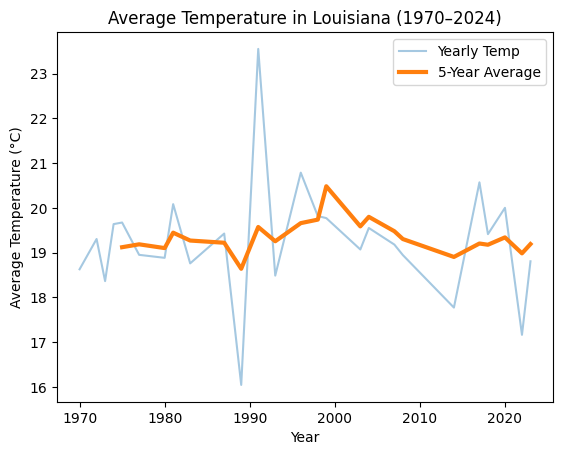

In [111]:
temp_yearly = (
    temp_pivot.groupby("year", as_index=False)["AVG_TEMP"]
    .mean()
    .sort_values("year")
) #grouped temperature data by year

temp_yearly["temp_smooth"] = temp_yearly["AVG_TEMP"].rolling(window=5).mean() #computed mean temperature for each year

import matplotlib.pyplot as plt

plt.plot(temp_yearly["year"], temp_yearly["AVG_TEMP"], alpha=0.4, label="Yearly Temp")
plt.plot(temp_yearly["year"], temp_yearly["temp_smooth"], linewidth=3, label="5-Year Average") #calculate 5 year rolling average, smoothing trend line

plt.xlabel("Year")
plt.ylabel("Average Temperature (°C)")
plt.title("Average Temperature in Louisiana (1970–2024)")
plt.legend()
plt.show() #Added labels, title, and legend for interpretability


The line graph above displays the average temperature in Louisiana from 1970 to 2024. The light blue line represents the yearly average temperature, while the orange line represents a five-year rolling average, which smooths short-term fluctuations and highlights longer-term temperature trends.

This visualization is important because yearly temperatures naturally fluctuate due to weather variability. The five-year moving average helps reveal broader patterns by reducing the effect of short-term spikes or drops. By smoothing the data, the overall trend becomes easier to interpret.

From the graph, we can see that although temperatures vary from year to year, the smoothed trend line suggests relatively stable temperatures with slight fluctuations over time. This type of visualization is useful for identifying long-term climate patterns and provides a foundation for comparing temperature trends with other environmental indicators, such as sea level changes in Louisiana.

# **Table 2**

This second table contains data on sea level measurements along the Louisiana coast. The dataset was obtained from the National Oceanic and Atmospheric Administration (NOAA) Tides and Currents program, which provides long-term observations from coastal tide gauge stations across the United States. The data used in this table comes from a Louisiana tide gauge station and includes monthly mean sea level measurements. Each row represents a specific month and year, and the variables include the year, month, the measured monthly mean sea level (Monthly_MSL), a calculated linear trend value, and high and low confidence interval estimates for the trend.

The team chose this dataset because sea level rise is one of the most significant consequences of climate change affecting coastal regions such as Louisiana. Rising sea levels can increase the risk of flooding, coastal erosion, and land loss, making this data especially relevant for understanding environmental change in the state. By analyzing this dataset alongside temperature data, the team can explore whether increasing temperatures correspond with changes in sea level trends. The dataset also provides long-term observations beginning in the mid-20th century, allowing for analysis of patterns and changes over several decades. Furthermore, because the data originates from NOAA, a well-established federal scientific agency, the dataset is considered reliable and credible for studying long-term environmental trends.

The sea level values include both positive and negative measurements because they are recorded relative to a reference datum rather than an absolute height. Positive values indicate months when sea level was above the reference level, while negative values indicate months when sea level was below it. These fluctuations are normal due to seasonal and environmental factors, but long-term trends can still reveal whether sea levels are increasing over time.


In [112]:
sealevel_df = pd.read_csv("/content/drive/MyDrive/Data Colab Notebooks/louisiana_sea_level.csv") #importing lousiana sea level data
sealevel_df.head()

,Year,Month,Monthly_MSL,Linear_Trend,High_Conf.,Low_Conf.
0,1947,1,-0.528,-0.618,-0.602,-0.634
1,1947,2,-0.619,-0.617,-0.601,-0.633
2,1947,3,-0.579,-0.616,-0.600,-0.633
3,1947,4,-0.582,-0.616,-0.600,-0.632
4,1947,5,-0.559,-0.615,-0.599,-0.631


We are removing hidden space from column names so each column can be inferred through panda as a variable

In [113]:
sealevel_df.columns = sealevel_df.columns.str.strip()

In [114]:
sealevel_df.columns #checking column names

Index(['Year', 'Month', 'Monthly_MSL', 'Linear_Trend', 'High_Conf.',
       'Low_Conf.'],
      dtype='object')

In [115]:
sealevel_df.dtypes #checking dtypes

,0
Year,int64
Month,int64
Monthly_MSL,float64
Linear_Trend,float64
High_Conf.,float64
Low_Conf.,float64


Both Year and Month are int64 so Panda recognizes them as quantitative variables, we now want to filter out the data from only 1970 to 2024, so it can match the previous data's time stamps

In [116]:
sealevel_df = sealevel_df[(sealevel_df["Year"] >= 1970) & (sealevel_df["Year"] <= 2024)].copy()

To make the sea level data easier to interpret, the measurements were converted from meters to centimeters by multiplying the values by 100. Using centimeters allows for clearer interpretation of smaller variations in sea level over time.

In [120]:
tidy_sea = sealevel_df[["Year","Month","Monthly_MSL"]].rename(
    columns={
        "Year":"year",
        "Month":"month",
        "Monthly_MSL":"sea_level"
    }
).sort_values(["year","month"])
tidy_sea.head()

,year,month,sea_level
271,1970,1,-0.479
272,1970,2,-0.500
273,1970,3,-0.390
274,1970,4,-0.375
275,1970,5,-0.337


## **Summary Statistics**

In [122]:
tidy_sea["sea_level"].mean()

np.float64(-0.1408161648177496)

The mean sea level value represents the average deviation from the reference level across the dataset. Because the measurements are recorded relative to a baseline rather than as absolute ocean height, positive values indicate months where sea level was above the reference level, while negative values indicate months where it was below it.

In [123]:
tidy_sea["sea_level"].max()

0.21

The maximum sea level value represents the largest positive deviation from the reference sea level during the observed time period, indicating the month when water levels were highest relative to the baseline.

# **Closing Thoughts and Final Goals**

The team is interested in exploring the relationship between the two datasets, as they both measure different environmental factors related to climate change in Louisiana. While the first dataset focuses on temperature patterns over time, including measurements such as maximum, minimum, and average temperatures, the second dataset focuses on changes in sea level along the Louisiana coast. Because both datasets measure environmental conditions over time, they can be compared to examine whether long-term increases in temperature correspond with observable changes in sea level. Questions such as, “Have temperatures in Louisiana increased over the past several decades?” “Has sea level along the Louisiana coast risen during the same time period?” and “Is there any relationship between temperature trends and changes in sea level?” are the types of questions the team is most interested in exploring.

To answer these questions, the team plans to tidy and transform both datasets in order to make them comparable, particularly by aligning the data by year and month where possible. This may involve filtering the data to a consistent time period, creating comparable variables, and merging the datasets to allow for direct comparisons. Once the data has been cleaned and organized, the team hopes to visualize trends over time and analyze whether any meaningful relationships exist between temperature changes and sea level measurements. Ultimately, the goal is to better understand how different environmental indicators may reflect broader climate change patterns affecting Louisiana’s coastal regions.

In [124]:
notebook_path = "/content/drive/MyDrive/Data Colab Notebooks/Elina_Mia_Final.ipynb"
!jupyter nbconvert --to html "{notebook_path}"


[NbConvertApp] Converting notebook /content/drive/MyDrive/Data Colab Notebooks/Elina_Mia_Final.ipynb to html
[NbConvertApp] WARNING | Alternative text is missing on 1 image(s).
[NbConvertApp] Writing 393364 bytes to /content/drive/MyDrive/Data Colab Notebooks/Elina_Mia_Final.html
